# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

## Dataset Preparation

The text data is loaded and cleaned before training. The dataset is converted into a suitable format for sequence generation.

In [19]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



## Tokenization

The text is tokenized to assign a unique integer to each word. Input sequences are then generated and padded to maintain a fixed length.

In [20]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
print("Sample word-index mapping:", dict(list(tokenizer.word_index.items())[:10]))

Vocabulary size: 37
Sample word-index mapping: {'deep': 1, 'learning': 2, 'is': 3, 'lstm': 4, 'models': 5, 'transforming': 6, 'artificial': 7, 'intelligence': 8, 'recurrent': 9, 'neural': 10}


In [21]:
input_sequences = []

for line in corpus.strip().split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Total sequences generated:", len(input_sequences))
print("Example sequences (first 3):")
for seq in input_sequences[:3]:
    print(" ", seq)

Total sequences generated: 35
Example sequences (first 3):
  [1, 2]
  [1, 2, 3]
  [1, 2, 3, 6]


In [22]:
max_len = max(len(seq) for seq in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_len, padding='pre'))
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
print("X shape:", X.shape, "  → input sequences")
print("y shape:", y.shape, "  → next word labels")
print("\nSample X[0]:", X[0])
print("Sample y[0]:", y[0], "→ word:", list(tokenizer.word_index.keys())[list(tokenizer.word_index.values()).index(y[0])])

X shape: (35, 7)   → input sequences
y shape: (35,)   → next word labels

Sample X[0]: [0 0 0 0 0 0 1]
Sample y[0]: 2 → word: learning


## Building the RNN Model

A simple recurrent neural network is created to learn patterns from sequential text. The model predicts the next word based on the previous words.

In [23]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    SimpleRNN(128, return_sequences=False),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)

final_rnn_loss = rnn_history.history['loss'][-1]
final_rnn_acc  = rnn_history.history['accuracy'][-1]
print(f"Vanilla RNN — Final Loss: {final_rnn_loss:.4f} | Final Accuracy: {final_rnn_acc:.4f}")

Vanilla RNN — Final Loss: 0.0758 | Final Accuracy: 0.9714


## Building the LSTM Model

An LSTM model is implemented to overcome the limitations of a standard RNN. It is capable of retaining important information for longer sequences.

In [25]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
final_lstm_loss = lstm_history.history['loss'][-1]
final_lstm_acc  = lstm_history.history['accuracy'][-1]
print(f"LSTM — Final Loss: {final_lstm_loss:.4f} | Final Accuracy: {final_lstm_acc:.4f}")

LSTM — Final Loss: 0.1861 | Final Accuracy: 0.9714


## Building the GRU Model

A GRU model is constructed as an alternative to LSTM. It contains fewer parameters while maintaining good performance on sequential data.

In [27]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
final_gru_loss = gru_history.history['loss'][-1]
final_gru_acc  = gru_history.history['accuracy'][-1]
print(f"GRU — Final Loss: {final_gru_loss:.4f} | Final Accuracy: {final_gru_acc:.4f}")

GRU — Final Loss: 0.0761 | Final Accuracy: 0.9714


## Model Training

Each model is trained using the same dataset and training parameters to allow a fair comparison of their performance.
The loss values are plotted to observe the learning progress of each model during training.
The trained models are used to generate text by predicting one word at a time from an initial input sequence.
The generated text, training loss, and number of trainable parameters are compared to evaluate the performance of the three models.

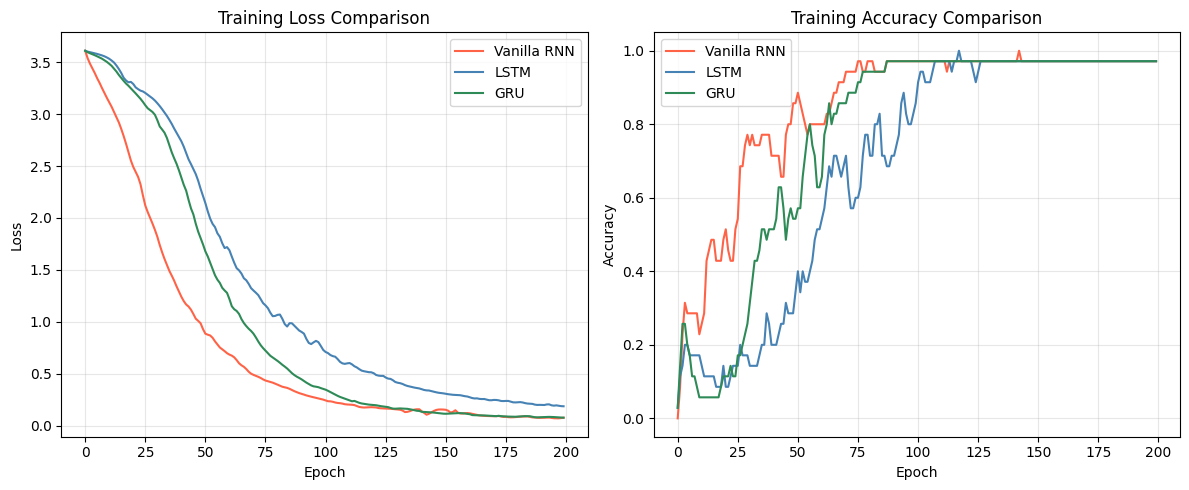


Final Metrics Summary
Model           Final Loss      Final Accuracy
Vanilla RNN     0.0758          0.9714
LSTM            0.1861          0.9714
GRU             0.0761          0.9714


In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['loss'],  label='Vanilla RNN',  color='tomato')
plt.plot(lstm_history.history['loss'], label='LSTM',         color='steelblue')
plt.plot(gru_history.history['loss'],  label='GRU',          color='seagreen')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['accuracy'],  label='Vanilla RNN',  color='tomato')
plt.plot(lstm_history.history['accuracy'], label='LSTM',         color='steelblue')
plt.plot(gru_history.history['accuracy'],  label='GRU',          color='seagreen')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Metrics Summary")
print(f"{'Model':<15} {'Final Loss':<15} {'Final Accuracy'}")
print(f"{'Vanilla RNN':<15} {final_rnn_loss:<15.4f} {final_rnn_acc:.4f}")
print(f"{'LSTM':<15} {final_lstm_loss:<15.4f} {final_lstm_acc:.4f}")
print(f"{'GRU':<15} {final_gru_loss:<15.4f} {final_gru_acc:.4f}")

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [30]:
def generate_text(model, seed_text, next_words=5):
    """
    Generates next_words words starting from seed_text.
    Uses greedy decoding (argmax at each step).
    """
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        predicted_idx = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_idx:
                output_word = word
                break
        result += " " + output_word
    return result

In [31]:
seed_phrases = ["deep learning", "lstm helps", "recurrent neural"]

print("TEXT GENERATION RESULTS (5 words each)")

for seed in seed_phrases:
    print(f"\nSeed: '{seed}'")
    print(f"  RNN : {generate_text(rnn_model,  seed, 5)}")
    print(f"  LSTM: {generate_text(lstm_model, seed, 5)}")
    print(f"  GRU : {generate_text(gru_model,  seed, 5)}")

TEXT GENERATION RESULTS (5 words each)

Seed: 'deep learning'
  RNN : deep learning models can generate meaningful sentences
  LSTM: deep learning models can generate meaningful sentences
  GRU : deep learning models can generate meaningful sentences

Seed: 'lstm helps'
  RNN : lstm helps remember long term dependencies data
  LSTM: lstm helps remember long term dependencies dependencies
  GRU : lstm helps remember long term dependencies dependencies

Seed: 'recurrent neural'
  RNN : recurrent neural networks are useful for sequential
  LSTM: recurrent neural networks are useful for sequential
  GRU : recurrent neural networks are useful for sequential


## 🧪 Generate Text Samples

In [32]:
print("Trainable parameter counts:")
print(f"  Vanilla RNN : {rnn_model.count_params():,}")
print(f"  LSTM        : {lstm_model.count_params():,}")
print(f"  GRU         : {gru_model.count_params():,}")


Trainable parameter counts:
  Vanilla RNN : 31,845
  LSTM        : 105,957
  GRU         : 81,637


## Conclusion

| Model | Strength | Weakness |
|-------|----------|----------|
| Vanilla RNN | Fast, simple | Vanishing gradient, poor long-term memory |
| LSTM | Best long-range memory | More parameters, slower to train |
| GRU | Good balance of speed + memory | Slightly less expressive than LSTM |

For short sequences like in this corpus, all three perform reasonably well. On longer texts with complex dependencies, LSTM and GRU will visibly outperform vanilla RNN — the loss curves will diverge more clearly.

One key insight worth remembering: the **embedding layer** does a lot of heavy lifting here. It converts sparse one-hot-style indices into dense 64-dimensional vectors, and those vectors gradually learn to cluster similar words together during training. That's actually where a lot of the model's "understanding" lives.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**